In [1]:
!mkdir -p /content/fashion_dataset
!unzip -q "/content/drive/MyDrive/Colab Notebooks/Glance Intern/val_test2020.zip" -d /content/fashion_dataset

In [52]:
import os

image_dir='/content/fashion_dataset'
valid_extensions=('.jpg', '.jpeg', '.png', '.webp')

image_paths=[]
for root,dirs,files in os.walk(image_dir):
    for file in files:
        if file.lower().endswith(valid_extensions):
            image_paths.append(os.path.join(root,file))

print(f"Total images extracted: {len(image_paths)}")

Total images extracted: 3200


In [3]:
!pip install -q pillow chromadb sentence-transformers torch torchvision tqdm transformers open_clip_torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.

In [16]:
import os
import json
import torch
import chromadb
from PIL import Image
from tqdm import tqdm
import open_clip
from transformers import BlipProcessor, BlipForQuestionAnswering

In [17]:
device="cuda" if torch.cuda.is_available() else "cpu"

In [18]:
vlm_processor=BlipProcessor.from_pretrained("Salesforce/blip-vqa-capfilt-large")
vlm_model=BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-capfilt-large").to(device)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/524 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/789 [00:00<?, ?it/s]

In [6]:
marqo_model,_,preprocess=open_clip.create_model_and_transforms('hf-hub:Marqo/marqo-fashionSigLIP')
tokenizer=open_clip.get_tokenizer('hf-hub:Marqo/marqo-fashionSigLIP')
marqo_model.eval().to(device)

open_clip_config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

open_clip_model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

CustomTextCLIP(
  (visual): TimmModel(
    (trunk): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
          

In [19]:
chroma_client=chromadb.PersistentClient(path="/content/chroma_db")
try:
    chroma_client.delete_collection(name="hybrid_fashion_index")
except Exception:
    pass
collection=chroma_client.get_or_create_collection(
    name="hybrid_fashion_index",
    metadata={"hnsw:space": "cosine"}
)

In [21]:
len(image_paths)

3200

In [23]:
vqa_queries={
    "garment_top": "what is the type of upper clothing?",
    "color_top": "what is the primary color of the upper clothing?",
    "garment_bottom": "what is the type of lower clothing?",
    "color_bottom": "what is the primary color of the lower clothing?",
    "environment": "what is the specific environment or setting backdrop?",
    "style": "is the clothing style formal, casual, or streetwear?",
    "action": "what action is the person performing, such as sitting, standing, or walking?"
}

In [24]:
for i,img_path in enumerate(tqdm(image_paths)):
    try:
        raw_image=Image.open(img_path).convert('RGB')

        structured_metadata={}
        for key, query_text in vqa_queries.items():
            inputs=vlm_processor(raw_image,query_text,return_tensors="pt").to(device)
            with torch.inference_mode():
                out=vlm_model.generate(**inputs,max_new_tokens=15)
            answer=vlm_processor.decode(out[0],skip_special_tokens=True).strip()
            structured_metadata[key]=answer if answer else "none"

        structured_metadata["image_path"]=img_path

        image_tensor=preprocess(raw_image).unsqueeze(0).to(device)
        with torch.inference_mode(), torch.cuda.amp.autocast():
            image_embedding=marqo_model.encode_image(image_tensor, normalize=True)

        embedding_list=image_embedding.cpu().tolist()[0]

        collection.add(
            embeddings=[embedding_list],
            metadatas=[structured_metadata],
            ids=[f"img_{i}"]
        )

    except Exception as e:
        print(f"\nError processing {img_path}: {e}")

print("\nIndexing Complete! Your database contains fully populated, real VLM attributes.")

  0%|          | 0/3200 [00:00<?, ?it/s]/tmp/ipykernel_473/3931006890.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast():
100%|██████████| 3200/3200 [39:06<00:00,  1.36it/s]


Indexing Complete! Your database contains fully populated, real VLM attributes.


## Retriever

In [25]:
import torch
import chromadb
from sentence_transformers import CrossEncoder
import open_clip

device="cuda" if torch.cuda.is_available() else "cpu"

In [26]:
from transformers import AutoModelForCausalLM, AutoTokenizer

parser_tokenizer=AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
parser_model=AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    torch_dtype=torch.float16,
    device_map="auto"
)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [27]:
marqo_model, _, _=open_clip.create_model_and_transforms('hf-hub:Marqo/marqo-fashionSigLIP')
tokenizer=open_clip.get_tokenizer('hf-hub:Marqo/marqo-fashionSigLIP')
marqo_model.eval().to(device)

CustomTextCLIP(
  (visual): TimmModel(
    (trunk): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
          

In [28]:
reranker=CrossEncoder("BAAI/bge-reranker-base")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [29]:
chroma_client=chromadb.PersistentClient(path="/content/chroma_db")
collection=chroma_client.get_collection(name="hybrid_fashion_index")

In [42]:
import re

def parse_query_live(raw_query):
    """Uses a live LLM to dynamically extract hard JSON filters from the user's text."""

    prompt=f"""You are a search query metadata extractor. Analyze the user's fashion search query and extract the specific details into a strictly formatted JSON object.
Only extract information explicitly mentioned. If a detail is not mentioned, use the value "none". Ignore accessories like ties, hats, or bags; focus only on the main garments.
Keys to extract: "garment_top", "color_top", "garment_bottom", "color_bottom", "environment", "action".

Example 1:
Query: "Someone wearing a blue shirt sitting on a park bench."
JSON output: {{"garment_top": "shirt", "color_top": "blue", "garment_bottom": "none", "color_bottom": "none", "environment": "park", "action": "sitting"}}

Example 2:
Query: "Professional business attire inside a modern office with black pants."
JSON output: {{"garment_top": "none", "color_top": "none", "garment_bottom": "pants", "color_bottom": "black", "environment": "office", "action": "none"}}

Example 3:
Query: "A red tie and a white shirt in a formal setting."
JSON output: {{"garment_top": "shirt", "color_top": "white", "garment_bottom": "none", "color_bottom": "none", "environment": "formal", "action": "none"}}

Query: "{raw_query}"
JSON output:"""

    messages=[
        {"role": "system", "content": "You output only valid JSON dictionaries without markdown formatting."},
        {"role": "user", "content": prompt}
    ]

    text=parser_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs=parser_tokenizer([text], return_tensors="pt").to(device)

    with torch.inference_mode():
        outputs=parser_model.generate(**inputs, max_new_tokens=100, temperature=0.1)

    response=parser_tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

    try:
        json_match=re.search(r'\{.*\}', response.strip(), re.DOTALL)
        if json_match:
            extracted_filters=json.loads(json_match.group(0))
            return {k: v.lower() for k, v in extracted_filters.items() if v.lower()!="none"}
        return {}
    except Exception as e:
        print(f"JSON Parsing failed. Fallback to vector-only search. Error: {e}")
        return {}

In [43]:
def search_fashion_hybrid(raw_query, top_k=3):
    print("\n"+"="*60)
    print(f"Input Query: '{raw_query}'")

    parsed_filters=parse_query_live(raw_query)
    print(f"LLM Extracted Filters: {parsed_filters}")

    where_clause=None
    if parsed_filters:
        if len(parsed_filters)>1:
            where_clause={"$and":[{k: {"$eq": v}} for k, v in parsed_filters.items()]}
        else:
            k,v=list(parsed_filters.items())[0]
            where_clause={k: {"$eq": v}}

    text_tokens=tokenizer([raw_query]).to(device)
    with torch.inference_mode(), torch.cuda.amp.autocast():
        query_embedding=marqo_model.encode_text(text_tokens, normalize=True).cpu().tolist()[0]

    initial_results=collection.query(
        query_embeddings=[query_embedding],
        n_results=30,
        where=where_clause
    )

    if not initial_results['metadatas'][0]:
        print("Strict metadata filter returned 0 results. Falling back to pure Semantic Vector Search.")
        initial_results=collection.query(
            query_embeddings=[query_embedding],
            n_results=20
        )

    metadatas=initial_results['metadatas'][0]

    if not metadatas:
        print("No matches found in the entire database.")
        return

    pairs=[]
    for meta in metadatas:
        candidate_caption=f"Action: {meta.get('action')}. Environment: {meta.get('environment')}. Upper: {meta.get('color_top')} {meta.get('garment_top')}. Lower: {meta.get('color_bottom')} {meta.get('garment_bottom')}."
        pairs.append([raw_query, candidate_caption])

    rerank_scores=reranker.predict(pairs)

    scored_candidates=list(zip(rerank_scores, metadatas))
    scored_candidates.sort(key=lambda x: x[0], reverse=True)

    print(f"\nFinal Top {top_k} Results:")
    print("="*60)
    for i in range(min(top_k, len(scored_candidates))):
        score, meta=scored_candidates[i]
        img_path=meta['image_path']

        print(f"Match #{i+1} | Semantic Re-Rank Score: {score:.4f}")
        print(f"Stored Metadata: Top({meta.get('color_top')} {meta.get('garment_top')}), Bottom({meta.get('color_bottom')} {meta.get('garment_bottom')}), Action({meta.get('action')}), Env({meta.get('environment')})")

        if os.path.exists(img_path):
            img=Image.open(img_path)
            img.thumbnail((300, 300))
            display(img)
        else:
            print(f"File missing: {img_path}")
        print("-" * 60)


Input Query: 'A person in a bright yellow raincoat.'
LLM Extracted Filters: {'garment_top': 'raincoat', 'color_top': 'yellow', 'environment': 'rain'}
   ⚠️ Strict metadata filter returned 0 results. Falling back to pure Semantic Vector Search.

Final Top 3 Results:
Match #1 | Semantic Re-Rank Score: 0.0264
Stored Metadata: Top(yellow raincoat), Bottom(red tights), Action(standing), Env(movie)


/tmp/ipykernel_473/1961449285.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast():


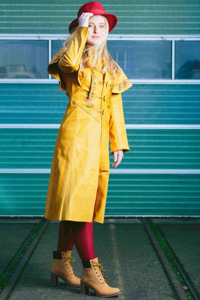

------------------------------------------------------------
Match #2 | Semantic Re-Rank Score: 0.0031
Stored Metadata: Top(yellow coat), Bottom(yellow pants), Action(walking), Env(urban)


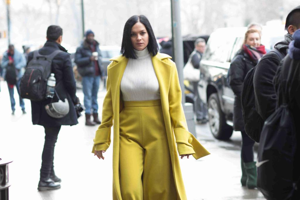

------------------------------------------------------------
Match #3 | Semantic Re-Rank Score: 0.0003
Stored Metadata: Top(tan coat), Bottom(black pants), Action(standing), Env(forest)


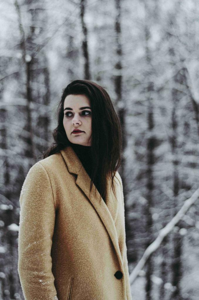

------------------------------------------------------------


In [44]:
search_fashion_hybrid("A person in a bright yellow raincoat.")


Input Query: 'Someone wearing a blue shirt sitting on a park bench.'
LLM Extracted Filters: {'garment_top': 'shirt', 'color_top': 'blue', 'environment': 'park', 'action': 'sitting'}

Final Top 3 Results:
Match #1 | Semantic Re-Rank Score: 0.8002
Stored Metadata: Top(blue shirt), Bottom(blue skirt), Action(sitting), Env(park)


/tmp/ipykernel_473/1961449285.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast():


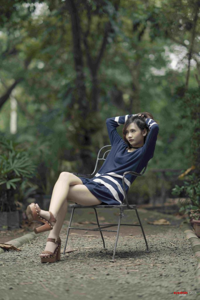

------------------------------------------------------------


In [45]:
search_fashion_hybrid("Someone wearing a blue shirt sitting on a park bench.")


Input Query: 'Professional business attire inside a modern office.'
LLM Extracted Filters: {'environment': 'modern office'}
   ⚠️ Strict metadata filter returned 0 results. Falling back to pure Semantic Vector Search.

Final Top 3 Results:
Match #1 | Semantic Re-Rank Score: 0.3170
Stored Metadata: Top(green shirt), Bottom(black pants), Action(sitting), Env(office)


/tmp/ipykernel_473/1961449285.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast():


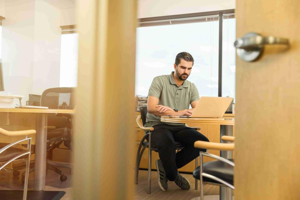

------------------------------------------------------------
Match #2 | Semantic Re-Rank Score: 0.2601
Stored Metadata: Top(blue shirt), Bottom(black shorts), Action(standing), Env(office)


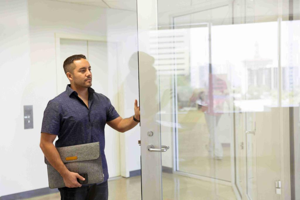

------------------------------------------------------------
Match #3 | Semantic Re-Rank Score: 0.1734
Stored Metadata: Top(gray suit jacket), Bottom(gray suit), Action(standing), Env(studio)


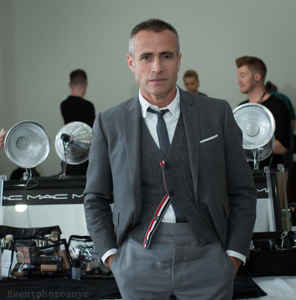

------------------------------------------------------------


In [46]:
search_fashion_hybrid("Professional business attire inside a modern office.")


Input Query: 'A red tie and a white shirt in a formal setting.'
LLM Extracted Filters: {'garment_top': 'tie', 'color_top': 'red', 'color_bottom': 'white', 'environment': 'formal'}
   ⚠️ Strict metadata filter returned 0 results. Falling back to pure Semantic Vector Search.

Final Top 5 Results:
Match #1 | Semantic Re-Rank Score: 0.0512
Stored Metadata: Top(white shirt), Bottom(black pants), Action(standing), Env(stage)


/tmp/ipykernel_473/1961449285.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast():


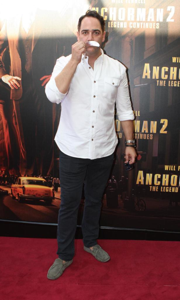

------------------------------------------------------------
Match #2 | Semantic Re-Rank Score: 0.0124
Stored Metadata: Top(white jacket), Bottom(red skirt), Action(standing), Env(stage)


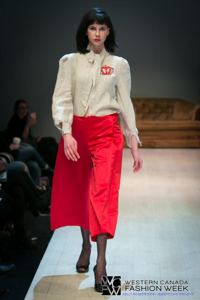

------------------------------------------------------------
Match #3 | Semantic Re-Rank Score: 0.0033
Stored Metadata: Top(red shirt), Bottom(black shorts), Action(standing), Env(stage)


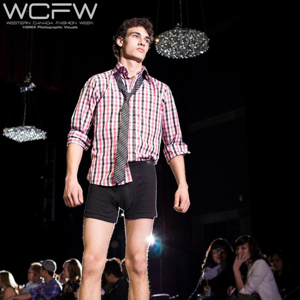

------------------------------------------------------------
Match #4 | Semantic Re-Rank Score: 0.0032
Stored Metadata: Top(red shirt), Bottom(red red pants), Action(sitting), Env(studio)


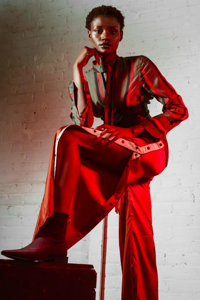

------------------------------------------------------------
Match #5 | Semantic Re-Rank Score: 0.0022
Stored Metadata: Top(white jacket), Bottom(black pants), Action(standing), Env(urban)


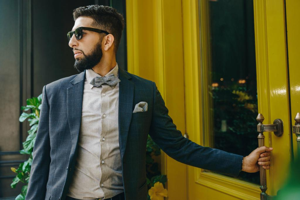

------------------------------------------------------------


In [50]:
search_fashion_hybrid("A red tie and a white shirt in a formal setting.",top_k=5)


Input Query: 'Casual weekend outfit for a city walk.'
LLM Extracted Filters: {'environment': 'city', 'action': 'walk'}
   ⚠️ Strict metadata filter returned 0 results. Falling back to pure Semantic Vector Search.

Final Top 5 Results:
Match #1 | Semantic Re-Rank Score: 0.6220
Stored Metadata: Top(pink pink shirt), Bottom(pink skirt), Action(walking), Env(city)


/tmp/ipykernel_473/1961449285.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast():


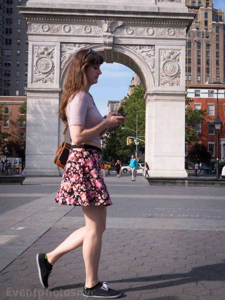

------------------------------------------------------------
Match #2 | Semantic Re-Rank Score: 0.3466
Stored Metadata: Top(gray sweatshirt), Bottom(blue jeans), Action(walking), Env(urban)


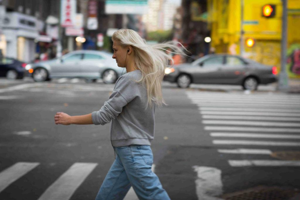

------------------------------------------------------------
Match #3 | Semantic Re-Rank Score: 0.3391
Stored Metadata: Top(blue blouse), Bottom(blue jeans), Action(walking), Env(urban)


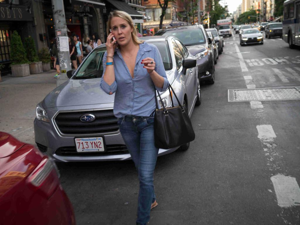

------------------------------------------------------------
Match #4 | Semantic Re-Rank Score: 0.2571
Stored Metadata: Top(white t shirt), Bottom(blue jeans), Action(walking), Env(urban)


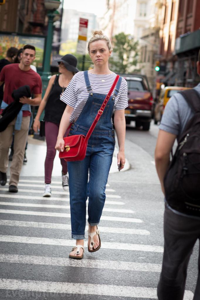

------------------------------------------------------------
Match #5 | Semantic Re-Rank Score: 0.1812
Stored Metadata: Top(black leather), Bottom(blue jeans), Action(walking), Env(urban)


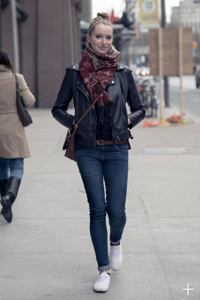

------------------------------------------------------------


In [51]:
search_fashion_hybrid("Casual weekend outfit for a city walk.",top_k=5)

In [41]:
import os
import shutil
from google.colab import drive

drive.mount('/content/drive')

source_db_path = '/content/chroma_db'
destination_db_path = '/content/drive/MyDrive/Colab Notebooks/Glance Intern/chroma_db'

os.makedirs(os.path.dirname(destination_db_path), exist_ok=True)

print(f"Copying vector store to: {destination_db_path}...")

shutil.copytree(source_db_path, destination_db_path, dirs_exist_ok=True)

print("Vector store safely backed up to your Glance Intern folder!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying vector store to: /content/drive/MyDrive/Colab Notebooks/Glance Intern/chroma_db...
Vector store safely backed up to your Glance Intern folder!
